### Running info
`ambertools` environment with NGLview installed from "conda-forge" NOT bioconda, and seaborn installed with pip

### Outline
Preparations to run ColabFold on adenylate kinases with ColabFold. ColabFold installed with the instructions here: https://git.embl.de/grp-kosinski/alphafold_howto/-/tree/main  


### Environment
`ambertools` to run this notebook. `ColabFold` to perform folding


Some old code at the end of the notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob

import os
import subprocess

from IPython.display import display, clear_output, IFrame
import IPython

In [2]:
%%javascript

IPython.OutputArea.auto_scroll_threshold = 9999

<IPython.core.display.Javascript object>

In [3]:
from __future__ import print_function
import warnings
warnings.filterwarnings('ignore') # make the notebook nicer


# import os
# os.environ['QT_QPA_PLATFORM']='offscreen'

import nglview as nv
import pytraj as pt

print("nglview version = {}".format(nv.__version__))
print("pytraj version = {}".format(pt.__version__))

from Bio.PDB import PDBParser, Select, PDBIO, Polypeptide
from Bio.SeqUtils import seq1

nglview version = 3.1.1
pytraj version = 2.0.6


In [4]:
from Bio import SeqIO
from Bio.SeqIO import FastaIO

In [5]:
import time

In [6]:
from ipywidgets import Box
from ipywidgets import Button, GridBox, Layout, ButtonStyle, Output
from jupyter_ui_poll import ui_events

### Outline


## 1. Load melnikov and GTDB data

In [7]:
%%time

# get GTDB data
gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)

gtdb_md_rep = gtdb_md[gtdb_md['gtdb_representative'].eq('t')].copy()

gtdb_md_rep['species'] = gtdb_md_rep['gtdb_taxonomy'].apply(lambda x: x.split(';')[-1].replace('s__', ''))

CPU times: user 11.6 s, sys: 1.11 s, total: 12.7 s
Wall time: 12.7 s


In [8]:
# load melnikov data
melnikov = pd.read_csv('./../data/ogt/Melnikov_bacteria_nbci_temperatures.csv')
melnikov['org_group'] = melnikov["Organism Groups"].apply(lambda x: x.split(';')[-1])

def reformat_col(old_col):
    new_col = old_col.lower().replace('(', ' ')
    for sub in ['%', ')', '#',]:
        new_col = new_col.replace(sub, '')
    return new_col.replace(' ', '_')

melnikov = melnikov.rename(columns=dict((s, reformat_col(s)) for s in melnikov.columns))
melnikov.head()

,organism_name,organism_groups,strain,biosample,bioproject,assembly,level,size_mb,gc,replicons,wgs,scaffolds,cds,release_date,genbank_ftp,refseq_ftp,temperature,org_group
0,Polaribacter irgensii 23-P,Bacteria;FCB group;Bacteroidetes/Chlorobi group,23-P,SAMN02436114,PRJNA13451,GCA_000153225.1,Scaffold,2.76346,34.6000,NaN,AAOG01,2,2352,2006-02-24T00:00:00Z,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000...,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,4.0,Bacteroidetes/Chlorobi group
1,Polaribacter filamentus,Bacteria;FCB group;Bacteroidetes/Chlorobi group,ATCC 700397,SAMN06074323,PRJNA355329,GCA_002943715.1,Contig,4.28193,31.4000,NaN,MQUA01,15,3545,2018-02-26T00:00:00Z,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/002...,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/002...,4.0,Bacteroidetes/Chlorobi group
2,Octadecabacter antarcticus 307,Bacteria;Proteobacteria;Alphaproteobacteria,307,SAMN02603621,PRJNA19333,GCA_000155675.2,Complete,4.87548,54.5768,chromosome:NC_020911.1/CP003740.1; plasmid pOA...,NaN,2,4421,2013-04-08T00:00:00Z,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000...,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,4.0,Alphaproteobacteria
3,Octadecabacter arcticus 238,Bacteria;Proteobacteria;Alphaproteobacteria,238,SAMN02603620,PRJNA19331,GCA_000155735.2,Complete,5.47825,55.1917,chromosome:NC_020908.1/CP003742.1; plasmid pOA...,NaN,3,4854,2013-04-08T00:00:00Z,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000...,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,4.0,Alphaproteobacteria
4,Shewanella violacea DSS12,Bacteria;Proteobacteria;Gammaproteobacteria,DSS12,SAMD00060963,PRJDA34739,GCA_000091325.1,Complete,4.96210,44.7000,chromosome:NC_014012.1/AP011177.1,NaN,1,3888,2010-04-01T23:08:00Z,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000...,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,4.0,Gammaproteobacteria


In [9]:
# merge melnikov and gtdb data
merged = pd.merge(melnikov[['organism_name', 'assembly', 'temperature']], 
                  gtdb_md_rep.reset_index()[['accession', 'ncbi_genbank_assembly_accession', 'species']],
                  left_on='assembly', right_on='ncbi_genbank_assembly_accession').dropna()

print(len(merged['accession'].unique()), len(merged))

merged.head()

9352 9352


,organism_name,assembly,temperature,accession,ncbi_genbank_assembly_accession,species
0,Polaribacter irgensii 23-P,GCA_000153225.1,4.0,RS_GCF_000153225.1,GCA_000153225.1,Polaribacter irgensii
1,Polaribacter filamentus,GCA_002943715.1,4.0,RS_GCF_002943715.1,GCA_002943715.1,Polaribacter filamentus
2,Octadecabacter antarcticus 307,GCA_000155675.2,4.0,RS_GCF_000155675.2,GCA_000155675.2,Octadecabacter antarcticus
3,Octadecabacter arcticus 238,GCA_000155735.2,4.0,RS_GCF_000155735.2,GCA_000155735.2,Octadecabacter arcticus
4,Shewanella violacea DSS12,GCA_000091325.1,4.0,RS_GCF_000091325.1,GCA_000091325.1,Shewanella violacea


## 2. Generate Pfam search results for all Melnikov genomes

In [10]:
merged = merged.set_index('accession')

In [11]:
accessions = list(merged.index.unique())
for a in accessions:
    os.system(f'cp /data/mhoffert/genomes/GTDB_r214.1/protein_faa_reps/bacteria/{a}_protein.faa.gz /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/genomes/')
    os.system('gunzip /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/genomes/*.gz')

with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/genomes/inds.txt', 'w') as handle:
    handle.write('\n'.join(accessions))

## functions

In [13]:
pfam_table_columns = ['target_name','target_accession','query_name','query_accession', 
                      'full_e_value', 'full_score', 'full_bias', 
                      'best_domain_e_value', 'best_domain_score', 'best_domain_bias', 
                      'exp', 'reg', 'clu',  'ov', 'env', 'dom', 'rep', 'inc', 'description_of_target']


def read_pfam_table_pandas(file_path : str) -> pd.DataFrame:
    """
    file_path: path to pfam "tblout"
    """
    # read table with special parameters
    pfam_as_table = pd.read_table(file_path, skiprows=3,  skipfooter=10, sep='\s+', header=None, engine='python')
    # un-split last 6 columns
    description = pfam_as_table.iloc[:, 18:].apply(lambda row: ''.join([str(v).lstrip() for v in row.values]), axis=1)
    # remove last 6 columns, add new one of joined values
    pfam_as_table = pfam_as_table.iloc[:, :18].assign(description_of_target=description.values)
    # reset column names
    pfam_as_table.columns = pfam_table_columns
    
    return pfam_as_table

## Read results and copy adk sequence to a new location

In [14]:
merged

,organism_name,assembly,temperature,ncbi_genbank_assembly_accession,species
accession,,,,,
RS_GCF_000153225.1,Polaribacter irgensii 23-P,GCA_000153225.1,4.0,GCA_000153225.1,Polaribacter irgensii
RS_GCF_002943715.1,Polaribacter filamentus,GCA_002943715.1,4.0,GCA_002943715.1,Polaribacter filamentus
RS_GCF_000155675.2,Octadecabacter antarcticus 307,GCA_000155675.2,4.0,GCA_000155675.2,Octadecabacter antarcticus
RS_GCF_000155735.2,Octadecabacter arcticus 238,GCA_000155735.2,4.0,GCA_000155735.2,Octadecabacter arcticus
RS_GCF_000091325.1,Shewanella violacea DSS12,GCA_000091325.1,4.0,GCA_000091325.1,Shewanella violacea
...,...,...,...,...,...
RS_GCF_000025605.1,Thermocrinis albus DSM 14484,GCA_000025605.1,80.0,GCA_000025605.1,Thermocrinis albus
RS_GCF_000512735.1,Thermocrinis ruber,GCA_000512735.1,80.0,GCA_000512735.1,Thermocrinis ruber
RS_GCF_000215975.1,Thermodesulfobacterium geofontis OPF15,GCA_000215975.1,80.0,GCA_000215975.1,Thermodesulfobacterium geofontis


In [15]:
pfam_tables = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/genomes/*_tblout.txt')

In [16]:
len(pfam_tables)

9352

In [24]:
count = 0
for file in pfam_tables:
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)
    try:
        df = read_pfam_table_pandas(file)
    except ValueError:
        print(f'Table contained no records:\n{file}')
        
    genome = file.split('/')[-1].split('_PF')[0]
    top_gene = df.sort_values('full_score', ascending=False).iloc[0, 0]
    bitscore = df.sort_values('full_score', ascending=False).iloc[0, 5]
    
    with open(file.replace('_PF00406_tblout.txt', '_protein.faa'), 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta') if top_gene in r.id]
    for r in records:
        r.seq = r.seq.replace('*', '')
        new_id = '|'.join([r.id.split(' # ')[0], 
                           genome, 
                           'adk', 
                           f'temp={merged.loc[genome, "temperature"]}',
                           f'bitscore={bitscore}'])
        r.id = new_id
        r.description = new_id

    outfile = file.replace('_PF00406_tblout.txt', '_adk.faa').replace('/genomes/', '/adks/')
    with open(outfile, 'w') as out_handle:
        SeqIO.write(records, out_handle, 'fasta')
    
    count += 1

9300

### SSN

In [25]:
with open('/data/mhoffert/geosmin/isolate_genomes/assembly/SA32_assembly/Streptomyces_coelicolor_A3(2)_strain.fasta', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, 'fasta')]

In [30]:
records[0].seq[1:100]

Seq('CCGCGGAGCGGGTACCACATCGCTGCGCGATGTGCGAGCGAACACCCGGGCTGC...CGC')

In [35]:
from Bio.SeqRecord import SeqRecord

In [37]:
encap_record = SeqRecord(records[0].seq[8535689-200:8537104+200])

In [40]:
encap_record.id = 'CP042324.1_7603'
encap_record.description = 'encapsulin f2b locus'

In [41]:
with open('/data/mhoffert/geosmin/isolate_genomes/assembly/SA32_assembly/encap_f2b.fasta', 'w') as handle:
    SeqIO.write([encap_record], handle, 'fasta')

In [57]:
pairwise = pd.read_csv('/data/mhoffert/fiererlab/ogt/results/colabfold/adk_pairwise.txt', sep='\t', header=None)

In [81]:
matched_genomes = blast_results[blast_results.pident > 50]['genome'].unique()
pairwise_colors = pd.Series(index=pairwise[0].unique(), 
                            data=['r' if s.split('|')[0] in matched_genomes else 'b' for s in pairwise[0].unique()])

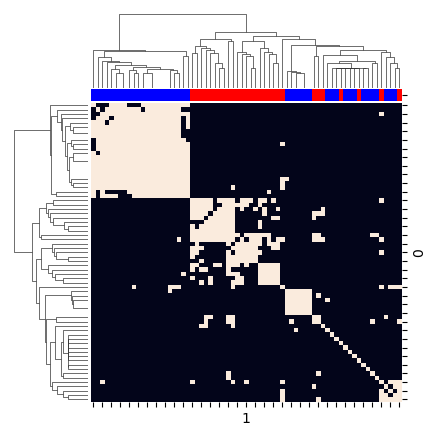

In [82]:
g = sns.clustermap(pairwise.groupby([0,1]).max()[2].unstack() > 50, col_colors=pairwise_colors)
g.ax_cbar.remove()
plt.tick_params(labelright=False, labelbottom=False)

### Notes
Not really worth doing an SSN. Nothing is that similar.

## Blast against Pdb  

In [26]:
# Running blast
genome_faas = glob.glob('/data/mhoffert/fiererlab/ogt/results/colabfold/adk_sequences/*')
base_path = '/data/mhoffert/fiererlab/ogt/results/colabfold/'
# blast each gene against the pdb sequence database
for g in genome_faas:
    genome = g.split('/')[-1].replace('.faa', '')
    display(genome, f'{genome_faas.index(g) / len(genome_faas) * 100:.2f}')
    clear_output(wait=True)
    command = f'blastp -query {g} -db /data/mhoffert/fiererlab/ogt/source_data/pdb_seqres -outfmt 6 -out {base_path}/pdb_blastout/{genome}_blast6out.txt'
    subprocess.check_output(command, shell=True)

'RS_GCF_001719065.1'

'99.77'

## Start here

In [27]:
# parsing blast hits to pdb
genome_blasts = glob.glob('/data/mhoffert/fiererlab/ogt/results/colabfold/pdb_blastout/*')
columns = 'qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore'.split(' ')
max_identities = []
blast_dfs = []
# for each output file
for b in genome_blasts:
    # get genome id
    genome = b.split('/')[-1].replace('_blast6out.txt', '')
    display(genome, f'{genome_blasts.index(b) / len(genome_blasts) * 100:.2f}')
    clear_output(wait=True)
    # read
    blast_df = pd.read_csv(b, sep='\t')
    blast_df.columns = columns
    # filter short hits
    blast_df = blast_df[blast_df.length > 50]
    # sort by pident
    blast_df.sort_values('pident', ascending=False, inplace=True)
    blast_dfs.append(blast_df.assign(genome=genome))
    max_identities.append(blast_df['pident'].max())
    

'RS_GCF_001719065.1'

'99.77'

(array([12., 18., 31., ...,  0.,  0.,  1.]),
 array([39.13    , 40.406425, 41.68285 , ..., 87.63415 , 88.910575,
        90.187   ]),
 <BarContainer object of 40 artists>)

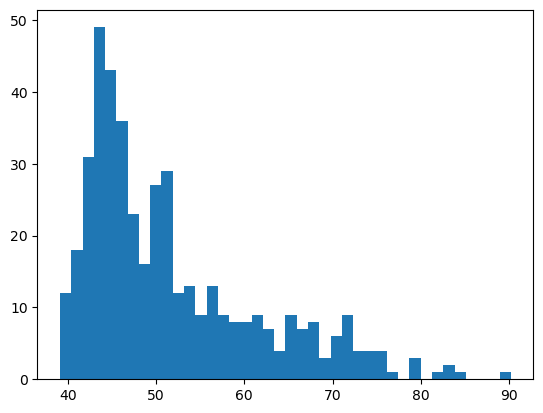

In [28]:
# plot of the maximum sequence identity of genome adk to pdb
plt.hist(max_identities, bins=40)

In [29]:
blast_results = pd.concat(blast_dfs).reset_index(drop=True)

In [30]:
blast_results['pdb_id'] = blast_results['sseqid'].apply(lambda x: x.split('_')[0])

In [31]:
len(blast_results[blast_results['pident'] > 50]['genome'].unique())

194

## Examine hits

from : https://stackoverflow.com/questions/22452748/remove-parts-from-a-pdb-file-using-python

http://nglviewer.org/nglview/latest/api.html?highlight=html#nglview.show_pytraj

https://ipywidgets.readthedocs.io/en/7.6.2/examples/Widget%20Events.html

https://stackoverflow.com/questions/61044884/adding-on-click-methods-to-buttons-created-with-ipywidgets

https://stackoverflow.com/questions/63784503/make-python-script-wait-for-button-click-ipywidgets

In [33]:
class ResSelect(Select):
    def __init__(self, chain_id):
        self.chain = chain_id
        
    def accept_residue(self, res):
        # print(vars(res))
        if res.parent.id == self.chain and Polypeptide.is_aa(res.resname):
            return True
        else:
            return False
        

#### Notes
There's a lot going on here. The specific solutions to problems I encountered came from the Stack overflow threads above. This section of code:
1. Iterates over each genome. For each genome:
2. Get all PDB chain hits over 50% amino acid identity. For each hit:
3. Download it, and save the individual chains to colabfold/pdb_files
4. Calculate the Lid-NMP distance for the domains, and determine whether the hit is "open" or "closed"
5. Potentially visualize the hit to manually classify
6. Save information on each hit for later use

In [37]:
# for each genome
template_data = pd.DataFrame(columns=['genome', 'id', 'pident', 'CL_dist', 'slen', 'conf'])
base_path = '/data/mhoffert/fiererlab/ogt/results/colabfold/pdb_files/'

valid_resnames = []
curr = 0

# for each genome
for genome in blast_results[blast_results.pident > 50].genome.unique():
    frac_genomes = list(blast_results[blast_results.pident > 50].genome.unique()).index(genome) / len(blast_results[blast_results.pident > 50].genome.unique())
    subset = blast_results[blast_results.genome.eq(genome) & (blast_results.pident > 50)].sort_values('sseqid').groupby(['genome', 'pdb_id']).first().reset_index()
    
    print(len(subset))
    # for each hit, starting with the best
    open_counts, closed_counts = 0, 0
    for index, row in subset.sort_values('pident', ascending=False).reset_index(drop=True).iterrows():
        frac_proteins = index / len(subset)
        clear_output(wait=True)
        # print(row)
        # get names
        protein, chain = row['sseqid'].split('_')
        print(f'{frac_genomes*100:.2f}', genome, f'{frac_proteins*100:.2f}', protein, chain)
        # move to next genome if 10 templates in each conformation have been identified
        if open_counts >= 10 and closed_counts >= 10:
            break
        # download
        try:
            if not os.path.exists(f'{base_path}/{protein}.pdb'):
                print('wgetting...')
                command = f'wget -P {base_path} https://files.rcsb.org/download/{protein}.pdb >/dev/null 2>&1'
                print(command)
            
                download_info = subprocess.check_output(command, shell=True)
            
            # first, get complete protein
            parser = PDBParser()
            structure = parser.get_structure(f"{protein}", f"{base_path}{protein}.pdb")
            
            # then, subset to matching chain with Bio.PDB.Select
            print('parsed')
            io = PDBIO()
            io.set_structure(structure)
            # save chain PDB
            io.save(f"{base_path}{protein}_{chain}.pdb", ResSelect(chain))
            # print('chains saved')
            
            # write chains for annotation
            slengths = {}
            chains = {chain.id:seq1(''.join(residue.resname for residue in chain if Polypeptide.is_aa(residue.resname))) for chain in structure.get_chains()}
            with open(f'{base_path}{protein}_chains.faa', 'w') as faa_handle:
                for key, item in chains.items():
                    faa_handle.write(f'>{protein}_chain_{key}\n')
                    faa_handle.write(item + '\n')
                    slengths[f'{protein}_{chain}'] = len(item)
            # print('chain faas saved')
            # then, load subset chain in pytraj
            # w = nv.show_biopython(structure[0][chain])
            print('trajectory loading...')
            
            traj = pt.load(f"{base_path}{protein}_{chain}.pdb")

            # print('distance and saving')
            distance = pt.distance(traj, ':119-154 :30-67')
            print('% id:',row['pident'],'open/closed:', open_counts, closed_counts, 'distance',distance)
            print(distance)
            conf = 'closed'
            if distance >= 25:
                conf = 'open'
            # elif distance >= 24:
            #     w = nv.show_pytraj(traj)
                
            #     # color residues in the core and lid domains
            #     scheme = nv.color._ColorScheme([['green', '119-154'], ['yellow', '30-67'], ['#FFA500', '7-13']], label='domains')
                
            #     w.clear()
            #     w.add_cartoon(color=scheme)
                
            #     # adding arrow
            #     p1 = list(pt.center_of_mass(traj, ':119-154')[0])
            #     p2 = list(pt.center_of_mass(traj, ':30-67')[0])
            #     w.shape.add_arrow(p1, p2, [1,0,0], 1.0)
                
            #     # button for actions
            #     open_butt = Button(description='open',
            #                      layout=Layout(width='auto', grid_area='open_butt'),
            #                      style=ButtonStyle(button_color='moccasin'))
            #     closed_butt = Button(description='closed',
            #                      layout=Layout(width='auto', grid_area='closed_butt'),
            #                      style=ButtonStyle(button_color='salmon'))
            #     # output widget type
            #     output = Output()
            #     # display all at once
            #     display(w, open_butt, closed_butt, output)
    
            #     # click events
            #     clicked = False
            #     conf = None
            #     def open_click(b):
            #         global clicked
            #         global conf
            #         clicked = True
            #         conf = 'open'
            #         with output:
            #             print('open')
                
            #     def closed_click(b):
            #         global clicked
            #         clicked = True
            #         global conf
            #         conf = 'closed'
            #         with output:
            #             print('closed')
                        
            #     open_butt.on_click(open_click)
            #     closed_butt.on_click(closed_click)
                
            #     # poll ui events to wait for click
            #     with ui_events() as poll:
            #         while not clicked:
            #             poll(10) # poll queued UI events including button
            #             time.sleep(0.5) # wait for 1 second before checking again
                

            else:
                conf = 'closed'

            print('waited for event, got final conf: ', conf)
            if conf == 'open':
                open_counts += 1
            else:
                closed_counts += 1
                
            # save data for this protein    
            template_data.loc[curr, 'genome'] = genome
            template_data.loc[curr, 'id'] = f'{protein}_{chain}'
            template_data.loc[curr, 'pident'] = row['pident']
            template_data.loc[curr, 'CL_dist'] = distance
            template_data.loc[curr, 'slen'] = slengths[f'{protein}_{chain}']
            template_data.loc[curr, 'conf'] = conf
            # time.sleep(1)

        except subprocess.CalledProcessError:
            print('Could not download!')

        curr += 1
        
        

99.48 RS_GCF_001719065.1 0.00 5g3z A
parsed
trajectory loading...
% id: 51.389 open/closed: 0 0 distance [23.3150303]
[23.3150303]
waited for event, got final conf:  closed


### Notes
Maybe a bad button

In [38]:
template_data['CL_dist'] = template_data['CL_dist'].astype(float) 

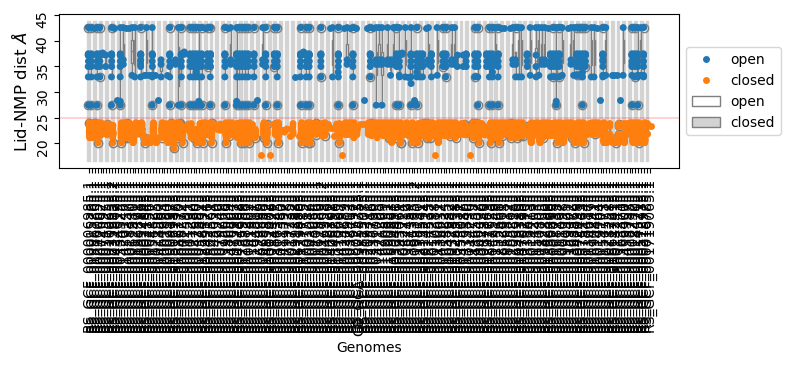

In [39]:
# plotting genome vs core to lid COM distance
fig, ax = plt.subplots(figsize=(8,2))
sns.stripplot(data=template_data, y='CL_dist', x='genome', hue='conf', dodge=True)
sns.boxplot(data=template_data, y='CL_dist', x='genome', hue='conf', dodge=True, palette=['white', 'lightgray'])
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Lid-NMP dist $\AA$', fontsize=12)
ax.set_xlabel('Genomes')
# xticks = ax.set_xticks(labels=range(len(ax.get_xticks())), rotation=90)
plt.tick_params(rotation=90)
ylims = ax.get_ylim()
for i in range(0, len(template_data['genome'].unique()), 2):
    ax.fill_betweenx(ylims, i-0.5, i + 0.5, color='lightgray', zorder=0)
yticks = ax.set_yticks(range(20, 50, 5))
ax.axhline(25, color='red', linewidth=0.25)

In [40]:
# save to tsv
template_data.to_csv('/data/mhoffert/fiererlab/ogt/results/colabfold/templates.tsv', sep='\t')

In [41]:
len(template_data['genome'].unique())

194

In [42]:
# genomes with both an open and closed template
co_genomes = template_data.groupby('genome').apply(lambda x: (x['conf'].value_counts() > 0).sum())
co_genomes = co_genomes[co_genomes > 1].index

In [43]:
len(co_genomes)

134

In [44]:
# for each genome with at least 1 open / 1 closed template
base_path = '/data/mhoffert/fiererlab/ogt/results/colabfold/'
for matched_genome in co_genomes:
    
    subset = template_data[template_data['genome'].eq(matched_genome)]
    count_str = ', '.join([str(s) for s in subset.conf.value_counts().values])
    print(matched_genome, 'closed, open', count_str)
    # make directory to hold templates for this genome
    for conf_dir in ['open', 'closed']:
        genome_templates_dir = f'{base_path}{conf_dir}_templates/{matched_genome}'
        if not os.path.exists(genome_templates_dir):
            os.mkdir(genome_templates_dir)
    # set conf
    for index, row in subset.iterrows():
        if row['conf'] == 'open':
            conf_dir = 'open'
        else:
            conf_dir = 'closed'
        # copy
        genome_templates_dir = f'{base_path}{conf_dir}_templates/{matched_genome}'
        old_template_path = f'{base_path}pdb_files/{row["id"]}.pdb'
        new_template_path = f'{genome_templates_dir}/{row["id"].split("_")[0]}.pdb'
        if not os.path.exists(new_template_path):
            os.system(f'cp {old_template_path} {new_template_path}')
        

RS_GCF_000006985.1 closed, open 26, 9
RS_GCF_000010985.1 closed, open 15, 2
RS_GCF_000012325.1 closed, open 26, 9
RS_GCF_000012865.1 closed, open 42, 10
RS_GCF_000015125.1 closed, open 34, 9
RS_GCF_000015285.1 closed, open 20, 9
RS_GCF_000018025.1 closed, open 47, 9
RS_GCF_000020465.1 closed, open 39, 9
RS_GCF_000020985.1 closed, open 43, 8
RS_GCF_000021545.1 closed, open 14, 2
RS_GCF_000021565.1 closed, open 14, 1
RS_GCF_000022325.1 closed, open 57, 10
RS_GCF_000024845.1 closed, open 13, 1
RS_GCF_000025605.1 closed, open 17, 1
RS_GCF_000025725.1 closed, open 10, 1
RS_GCF_000091325.1 closed, open 30, 9
RS_GCF_000144645.1 closed, open 28, 1
RS_GCF_000145215.1 closed, open 56, 10
RS_GCF_000172975.1 closed, open 39, 7
RS_GCF_000177635.2 closed, open 25, 8
RS_GCF_000183405.1 closed, open 22, 1
RS_GCF_000184345.1 closed, open 16, 7
RS_GCF_000184705.1 closed, open 45, 8
RS_GCF_000191045.1 closed, open 1, 1
RS_GCF_000194135.1 closed, open 41, 2
RS_GCF_000215975.1 closed, open 58, 9
RS_GCF_000

In [45]:
with open('/data/mhoffert/fiererlab/ogt/results/colabfold/inds.txt', 'w') as handle:
    handle.write('\n'.join(co_genomes))

In [ ]:
# copy additional open templates in
# for each genome with at least 1 open / 1 closed template
base_path = '/data/mhoffert/fiererlab/ogt/results/colabfold/'
for matched_genome in co_genomes:
    

## Assess folding

In [11]:
from io import StringIO

In [12]:
# functions to assess models and conformation

def AssessConf(file: str, plot: bool=False, verbose: bool=False):
    '''
    file : str -> filepath of pdb file
    plot : bool -> draw an interactive widget?
    '''
    # load trajectory
    traj = pt.load(file)
    w = nv.show_pytraj(traj)
    
    # print('distance and saving')
    distance = pt.distance(traj, ':119-154 :30-67')
    conf = 'closed'
    if distance >= 25:
        conf = 'open'
    
    if verbose:
        print('Core-lid distance: ', distance[0], f' likely conf is {conf}')
    
    # color residues in the core and lid domains
    scheme = nv.color._ColorScheme([['green', '119-154'], ['yellow', '30-67'], ['#FFA500', '7-13']], label='domains')
    
    w.clear()
    w.add_cartoon(color=scheme)
    
    # adding arrow
    p1 = list(pt.center_of_mass(traj, ':119-154')[0])
    p2 = list(pt.center_of_mass(traj, ':30-67')[0])
    w.shape.add_arrow(p1, p2, [1,0,0], 1.0)

    if plot:
        display(w)

    return distance[0]

def GetFinalModels(file: str):
    with open(file, 'r') as handle:
        lines = [l for l in handle.readlines() if 'rank_' in l]
    
    # load
    df = pd.read_csv(StringIO(''.join(lines)), 
                     sep=' ',
                     header=None)
    # # rename cols
    df.columns = ['date', 'time', 'model',  'plddt', 'ptm']
    df = df.reindex(columns=['date', 'time', 'model', 'recycle', 'plddt', 'ptm', 'tol'])
    df['recycle'] = -1
    df['final'] = True
    return df

def ReadColabLog(file: str):
    '''
    Take a colab log file and report all of the stats for each model
    '''
    # read file
    with open(file, 'r') as handle:
        lines = [l for l in handle.readlines() if 'recycle' in l]
    lines[0] = lines[0].replace('\n', ' tol=0\n')

    # load
    df = pd.read_csv(StringIO(''.join(lines)), 
                     sep=' ',
                     header=None)
    # rename cols
    df.columns = ['date', 'time', 'model','recycle', 'plddt', 'ptm', 'tol']
    df['final'] = False
    # remove intervening lines
    df = df[~df['recycle'].eq('took')]

    df = pd.concat([df, GetFinalModels(file)])
    
    # turns some cols to floats
    for col in ['recycle', 'plddt', 'ptm', 'tol']:
        df[col] = df[col].apply(lambda x: x.split('=')[-1] if isinstance(x, str) else x).astype(float)
    
    # add a "template" and "genome" col
    splits = file.split('/')[-2].split('_')
    template_conf = splits[-1]
    genome = '_'.join(splits[:-1])
    df['genome'] = genome
    df['template_conf'] = template_conf

    # add a pdb file and conformation column
    basepath = '/'.join(file.split('/')[:-1]) + '/'

    df['pdb_file'] = ''
    
    # get pdb files for non-finalized models
    df['pdb_file'] = df.apply(lambda row: glob.glob(f'{basepath}*{row["model"]}*r{int(row["recycle"])}*pdb')[0] \
                                            if not row['final'] else \
                                            glob.glob(f'{basepath}*_relaxed_*{row["model"]}.pdb')[0],
                                       axis=1)

    
    df['distance'] = df['pdb_file'].apply(lambda x: AssessConf(x, False))
    df['conf'] = df['distance'].apply(lambda x: 'open' if x > 25 else 'closed')
    df['relaxed'] = df['pdb_file'].apply(lambda x: '_relaxed_' in x)
    
    return df
    

def DetermineBestModel(file: str,  ax, template_conf = 'open',):
    '''
    file : str -> filepath of ColabFold batch log file
    plot : Bool -> draw a summary of the statistics? 
    '''
    genome = file.split('/')[-2]
    print(genome)
    # get file contents
    df = ReadColabLog(file)
    try:
        # plot
        x, y = 'ptm', 'plddt'
        sns.scatterplot(data=df, x=x, y=y, hue='model', 
                        style='conf', style_order=['open', 'closed'], markers=['o', 'v'],
                        size='final', 
                        size_order=[True, False], ax=ax)
        ylims = ax.get_ylim()
        xlims = ax.get_xlim()
        ax.set_ylim(ylims[0] * 0.99, ylims[1] * 1.01)
        ax.set_xlim(xlims[0] * 0.99, xlims[1] * 1.01)
        
        # need to fix this global variable reference
        num_templates = template_data.groupby(['genome', 'conf']).count().loc[(genome.replace(f'_{template_conf}', ''), template_conf), 'id']
        ax.set_title(f'Templates: {num_templates} {template_conf}')
        return (True, ax)
    except IndexError:
        print('Model is not done running')
        return (False, ax)

    

### Relaxation code
https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/beta/relax_amber.ipynb#scrollTo=1KKjet38pMys

In [7]:
logs = glob.glob('/data/mhoffert/fiererlab/ogt/results/colabfold/out_run2/*/*log.txt')

In [8]:
num_complete = len([l for l in logs if 'open' in l])
logs_reorder = sorted(logs)[:num_complete * 2]

In [9]:
len(logs_reorder)

124

In [13]:
model_output_path = '/data/mhoffert/fiererlab/ogt/results/colabfold/finalized_models/'
unrelaxed_path = '/data/mhoffert/fiererlab/ogt/results/colabfold/to_relax_models/'
best_model_stats_list = []
for i in range(len(logs_reorder)):
    splits = logs_reorder[i].split('/')[-2].split('_')
    genome = '_'.join(splits[:-1])
    desired_conf = splits[-1]
    # print(genome, desired_conf)
    # if not os.path.exists(f'{model_output_path}{genome}_{desired_conf}.pdb'):
    
    model_df = ReadColabLog(logs_reorder[i]).reset_index(drop=True)
    # genome = model_df['genome'].unique()[0]
    # desired_conf = logs_reorder[i].split('/')[-2].split('_')[-1]
    model_df = model_df[model_df['conf'].eq(desired_conf)]

    if model_df.shape[0] > 0:
        if model_df[model_df['final']].shape[0] > 1:
            best_model = model_df[model_df['model'].str.contains('rank_001')].index[0]
        elif model_df[model_df['final']].shape[0] == 1:
            best_model = model_df[model_df['final']].index[0]
        else:
            best_model = model_df['plddt'].idxmax()
        
        print(best_model)
        best_model_stats = model_df.loc[best_model, :]
        best_model_stats_list.append(best_model_stats)
        if not best_model_stats['relaxed']:
            pdb_file = best_model_stats["pdb_file"].split('/')[-1]
            # insert relaxation code here
            relaxed_path = f'{unrelaxed_path}{pdb_file.replace("_unrelaxed_", "_relaxed_")}'
            if os.path.exists(relaxed_path):
                print('Found a relaxed model... copying...')
                os.system(f'cp {relaxed_path} {model_output_path}{genome}_{best_model_stats["conf"]}.pdb')
            else:
                print('Uh oh - no relaxed model found!')
                os.system(f'cp {best_model_stats["pdb_file"]} {unrelaxed_path}')
            
        else:
            if best_model_stats['conf'] != desired_conf:
                print('Uh oh - conformation is wrong!')
            else:
                print(genome)
                print('copied a model:', ', '.join(['='.join([str(k),str(v)]) for k,v in best_model_stats[['model', 'relaxed', 'conf', 'recycle']].items()]))
                os.system(f'cp {best_model_stats["pdb_file"]} {model_output_path}{genome}_{best_model_stats["conf"]}.pdb')

    

16
RS_GCF_000006985.1
copied a model: model=rank_001_alphafold2_ptm_model_1_seed_1040, relaxed=True, conf=closed, recycle=-1.0
0
Uh oh - no relaxed model found!
16
RS_GCF_000010985.1
copied a model: model=rank_001_alphafold2_ptm_model_1_seed_1040, relaxed=True, conf=closed, recycle=-1.0
0
Found a relaxed model... copying...
16
RS_GCF_000012325.1
copied a model: model=rank_001_alphafold2_ptm_model_1_seed_1040, relaxed=True, conf=closed, recycle=-1.0
16
RS_GCF_000012325.1
copied a model: model=rank_001_alphafold2_ptm_model_1_seed_1040, relaxed=True, conf=open, recycle=-1.0
16
RS_GCF_000012865.1
copied a model: model=rank_001_alphafold2_ptm_model_1_seed_1040, relaxed=True, conf=closed, recycle=-1.0
17
RS_GCF_000012865.1
copied a model: model=rank_002_alphafold2_ptm_model_2_seed_1040, relaxed=True, conf=open, recycle=-1.0
16
RS_GCF_000015125.1
copied a model: model=rank_001_alphafold2_ptm_model_1_seed_1040, relaxed=True, conf=closed, recycle=-1.0
8
Found a relaxed model... copying...
16
RS

EmptyDataError: No columns to parse from file

In [22]:
finalized_models = pd.concat(best_model_stats_list, axis=1).T
finalized_models['temp'] = finalized_models['pdb_file'].apply(lambda x: x.split('_temp_')[-1].split('_')[0])
finalized_models['relaxed'] = True
finalized_models.to_csv('/data/mhoffert/fiererlab/ogt/results/colabfold/20231024_model_info.tsv')

In [26]:
finalized_models.groupby('genome').first()['temp'].astype(float).to_csv('/data/mhoffert/fiererlab/ogt/results/colabfold/genome2temp.csv')

In [51]:
AssessConf('/data/mhoffert/fiererlab/ogt/results/colabfold/finalized_models/RS_GCF_000006985.1_open.pdb', plot=True)

NGLWidget()

32.67594590242567

closed
RS_GCF_000006985.1_closed
open
RS_GCF_000006985.1_open


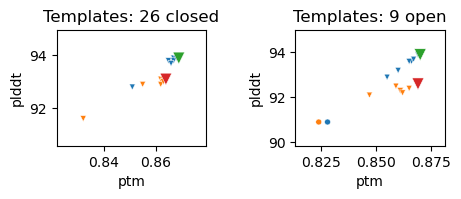

closed
RS_GCF_000010985.1_closed
open
RS_GCF_000010985.1_open


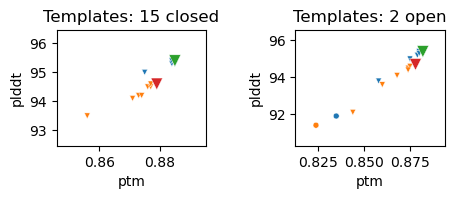

closed
RS_GCF_000012325.1_closed
open
RS_GCF_000012325.1_open


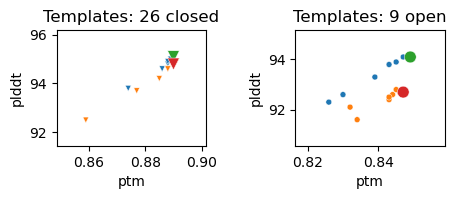

closed
RS_GCF_000012865.1_closed
open
RS_GCF_000012865.1_open


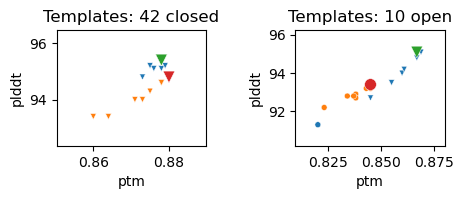

closed
RS_GCF_000015125.1_closed
open
RS_GCF_000015125.1_open


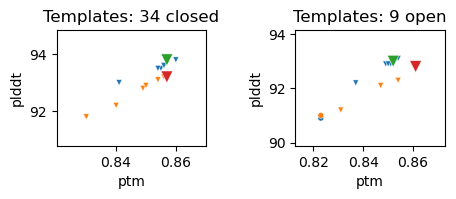

closed
RS_GCF_000015285.1_closed
open
RS_GCF_000015285.1_open


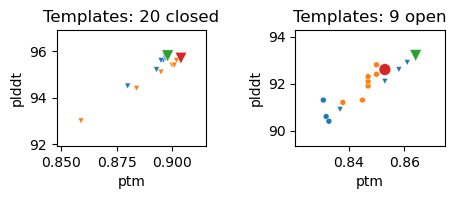

closed
RS_GCF_000018025.1_closed
open
RS_GCF_000018025.1_open


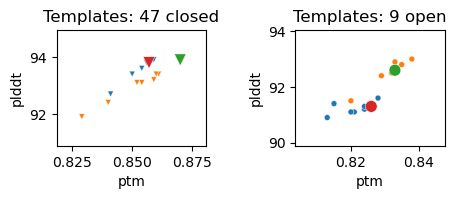

closed
RS_GCF_000020465.1_closed
open
RS_GCF_000020465.1_open


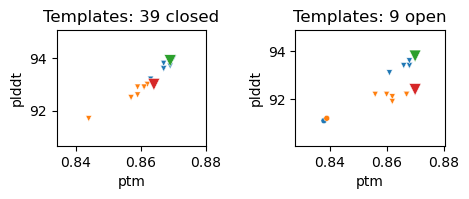

closed
RS_GCF_000020985.1_closed
open
RS_GCF_000020985.1_open


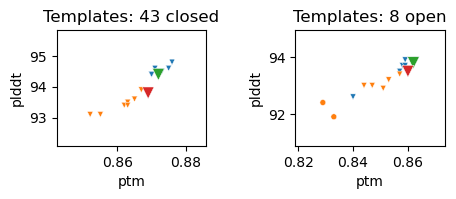

closed
RS_GCF_000021545.1_closed
open
RS_GCF_000021545.1_open


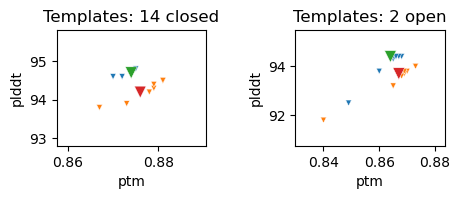

closed
RS_GCF_000021565.1_closed
open
RS_GCF_000021565.1_open


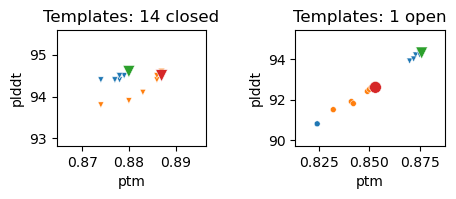

closed
RS_GCF_000022325.1_closed
open
RS_GCF_000022325.1_open


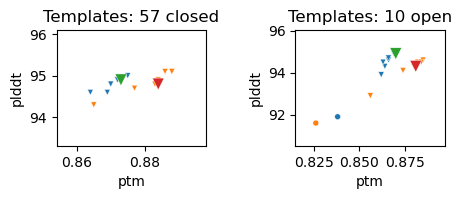

closed
RS_GCF_000024845.1_closed
open
RS_GCF_000024845.1_open


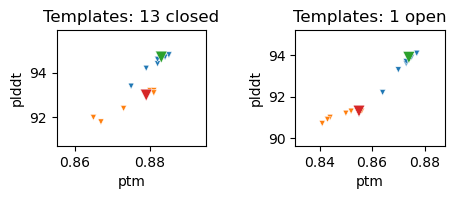

closed
RS_GCF_000025605.1_closed
open
RS_GCF_000025605.1_open


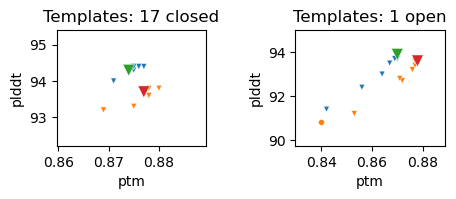

closed
RS_GCF_000025725.1_closed
open
RS_GCF_000025725.1_open


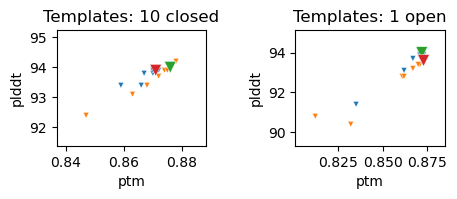

closed
RS_GCF_000091325.1_closed
open
RS_GCF_000091325.1_open


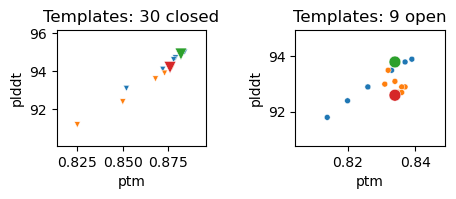

closed
RS_GCF_000144645.1_closed
open
RS_GCF_000144645.1_open


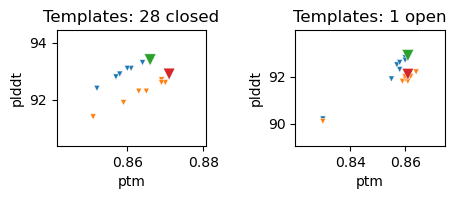

closed
RS_GCF_000145215.1_closed
open
RS_GCF_000145215.1_open


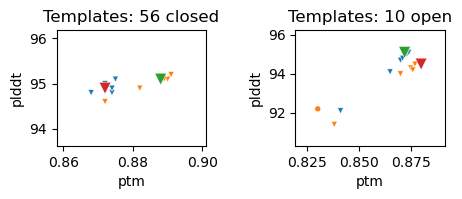

closed
RS_GCF_000172975.1_closed
open
RS_GCF_000172975.1_open


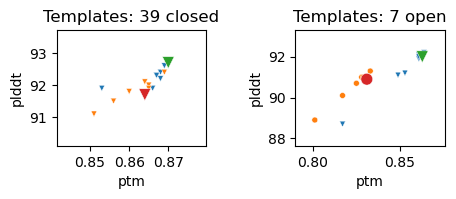

closed
RS_GCF_000177635.2_closed
open
RS_GCF_000177635.2_open


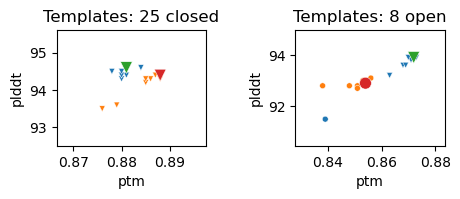

closed
RS_GCF_000183405.1_closed
open
RS_GCF_000183405.1_open


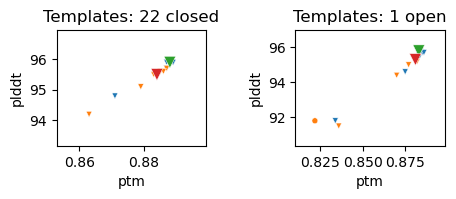

closed
RS_GCF_000184345.1_closed
open
RS_GCF_000184345.1_open


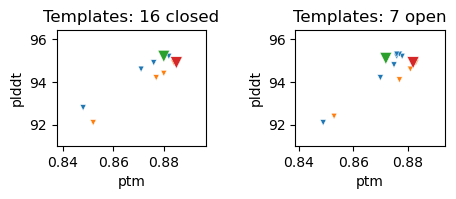

closed
RS_GCF_000184705.1_closed
open
RS_GCF_000184705.1_open


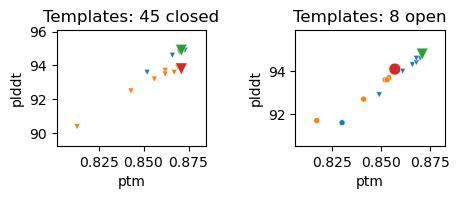

closed
RS_GCF_000191045.1_closed
open
RS_GCF_000191045.1_open


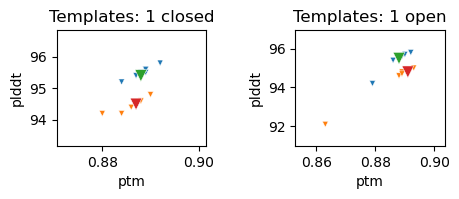

In [16]:
i = 1
num_complete = len([l for l in logs if 'open' in l])
logs_reorder = sorted(logs)[:num_complete * 2]

for log in range(0, len(logs_reorder), 2):
    fig = plt.figure(figsize=(5,1.5))
    for i in [0,1]:
        template_conf = logs_reorder[log+i].split('/')[-2].split('_')[-1]
        print(template_conf)
        ax = fig.add_subplot(1, 2, i + 1)
        result1, ax = DetermineBestModel(logs_reorder[log+i],  ax, template_conf)
        if result1:
            ax.get_legend().remove()
    fig.subplots_adjust(wspace=0.6, hspace=0.6)
    plt.show()

## End of Code

In [233]:
ReadColabLog('/data/mhoffert/fiererlab/ogt/results/colabfold/out_run2/RS_GCF_000012325.1_open/log.txt')

,date,time,model,recycle,plddt,ptm,tol,final,genome,template_conf,pdb_file,distance,conf,relaxed
0,2023-10-18,"05:22:23,670",alphafold2_ptm_model_1_seed_1040,0.0,92.3,0.826,0.0000,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,31.595031,open,False
1,2023-10-18,"05:54:37,121",alphafold2_ptm_model_1_seed_1040,1.0,92.6,0.830,0.2570,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,31.974275,open,False
2,2023-10-18,"06:25:09,019",alphafold2_ptm_model_1_seed_1040,2.0,93.3,0.839,0.2250,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,32.539998,open,False
3,2023-10-18,"06:55:05,690",alphafold2_ptm_model_1_seed_1040,3.0,93.8,0.843,0.0806,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,32.676668,open,False
4,2023-10-18,"07:25:40,324",alphafold2_ptm_model_1_seed_1040,4.0,94.1,0.848,0.0455,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,32.624981,open,False
5,2023-10-18,"07:56:33,266",alphafold2_ptm_model_1_seed_1040,5.0,93.9,0.845,0.0966,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,32.859336,open,False
6,2023-10-18,"08:28:39,041",alphafold2_ptm_model_1_seed_1040,6.0,94.1,0.847,0.0620,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,32.858229,open,False
7,2023-10-18,"08:59:54,738",alphafold2_ptm_model_1_seed_1040,7.0,94.1,0.849,0.0839,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,32.688960,open,False
9,2023-10-18,"09:30:30,218",alphafold2_ptm_model_2_seed_1040,0.0,92.1,0.832,NaN,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,29.646423,open,False
10,2023-10-18,"10:01:23,180",alphafold2_ptm_model_2_seed_1040,1.0,91.6,0.834,0.7200,False,RS_GCF_000012325.1,open,/data/mhoffert/fiererlab/ogt/results/colabfold...,29.530575,open,False


In [ ]:
'/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000012865.1_open/

In [287]:
logs

['/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000006985.1_closed/log.txt',
 '/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000006985.1_open/log.txt',
 '/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000012865.1_closed/log.txt',
 '/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000012865.1_open/log.txt',
 '/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000015285.1_closed/log.txt',
 '/data/mhoffert/fiererlab/ogt/results/colabfold/colabfold/out_run2/RS_GCF_000015285.1_open/log.txt']

In [262]:
AssessConf('/data/mhoffert/fiererlab/ogt/results/colabfold/open_templates/1zd8.pdb', plot=True)

Core-lid distance:  33.914549548155755  likely conf is open


NGLWidget()

33.914549548155755

In [80]:
# write genomes to inds file
with open('/data/mhoffert/fiererlab/ogt/results/colabfold/run2_matched_genomes.txt', 'w') as handle:
    handle.write('\n'.join(co_genomes))

In [72]:
subset

,genome,id,pident,CL_dist,slen,conf
389,RS_GCF_900215655.1,4jky_A,58.049,21.015007,203,closed
390,RS_GCF_900215655.1,4jl5_A,58.049,20.619228,203,closed
391,RS_GCF_900215655.1,4jl6_A,58.049,20.547678,203,closed
392,RS_GCF_900215655.1,4jl8_A,58.049,20.442941,203,closed
393,RS_GCF_900215655.1,4jla_A,58.049,20.571706,203,closed
394,RS_GCF_900215655.1,4jlb_A,58.049,20.559921,203,closed
395,RS_GCF_900215655.1,4jld_A,58.049,20.622193,203,closed
396,RS_GCF_900215655.1,4jlo_A,57.561,20.193196,203,closed
397,RS_GCF_900215655.1,4jlp_A,57.561,20.894370,203,closed
398,RS_GCF_900215655.1,2rgx_A,56.872,20.885754,203,closed


In [105]:
template_data['CL_dist'] = template_data['CL_dist'].astype(float)
template_data.dropna().sort_values('CL_dist', ascending=False)

,genome,id,pident,CL_dist,slen
0,RS_GCF_000006985.1,3gmt_A,65.116,42.570052,199
16,RS_GCF_000006985.1,6rze_A,60.377,37.458138,214
18,RS_GCF_000006985.1,4x8h_A,60.377,37.389441,214
8,RS_GCF_000006985.1,4ake_A,60.849,37.215355,214
15,RS_GCF_000006985.1,6s36_A,60.377,37.146353,214
13,RS_GCF_000006985.1,4x8m_A,60.377,36.016604,214
5,RS_GCF_000006985.1,6f7u_A,60.849,34.986179,214
25,RS_GCF_000006985.1,4np6_A,58.333,32.960532,211
27,RS_GCF_000006985.1,4pzl_A,52.995,27.453997,218
31,RS_GCF_000006985.1,4qbf_A,51.5,24.051612,216


In [ ]:
traj = pt.load(f"{base_path}3x2s_A.pdb")
# w_to_traj = nv.PyTrajTrajectory(w)
w = nv.show_pytraj(traj)
print('distance and saving')
distance = pt.distance(traj, ':119-154 :30-67')

print(distance)
template_data.loc[curr, 'genome'] = genome
template_data.loc[curr, 'id'] = f'{protein}_{chain}'
template_data.loc[curr, 'CL_dist'] = distance
template_data.loc[curr, 'pident'] = row['pident']
    
scheme = nv.color._ColorScheme([['green', '119-154'], ['yellow', '30-67'], ['#FFA500', '7-13']], label='domains')

w.clear()
w.add_cartoon(color=scheme)

p1 = list(pt.center_of_mass(traj, ':119-154')[0])
p2 = list(pt.center_of_mass(traj, ':30-67')[0])
w.shape.add_arrow(p1, p2, [1,0,0], 1.0)
# x axis arrow, red
w.shape.add_arrow([0,0,0], [25,0,0], [1,0,0], 0.25)

# y axis arrow, green
w.shape.add_arrow([0,0,0], [0, 25,0], [0,1,0], 0.25)

# z axis arrow, blue
w.shape.add_arrow([0,0,0], [0,0,25], [0,0,1], 0.25)

# w.control.spin([0,1,0], radians(180))
# # z_rot = rot_angle([p1[2], p1[1]], [p2[2], p2[1]])
# x_rot = rot_angle([p1[0], p1[1]], [p2[0], p2[1]])
# w.control.spin([1,0,0], radians(x_rot))

# y_rot = rot_angle([p1[1], p1[2]], [p2[1], p2[2]])
# w.control.spin([0,1,0], radians(y_rot))
# w.shape.add_arrow([0,0,0], [10,10,10], [1,1,1], 1.0)

w

In [69]:
for prot in ['5eje', '3x2s']:
    clear_output(wait=True)
    print(prot)
    traj = pt.load(f"{base_path}{prot}_A.pdb")
    w = nv.show_pytraj(traj)
    print('distance and saving')
    distance = pt.distance(traj, ':119-154 :30-67')
    
    print(distance)
        
    scheme = nv.color._ColorScheme([['green', '119-154'], ['yellow', '30-67'], ['#FFA500', '7-13']], label='domains')
    
    w.clear()
    w.add_cartoon(color=scheme)
    
    p1 = list(pt.center_of_mass(traj, ':119-154')[0])
    p2 = list(pt.center_of_mass(traj, ':30-67')[0])
    w.shape.add_arrow(p1, p2, [1,0,0], 1.0)
    
    
    
    open_butt = Button(description='open',
                     layout=Layout(width='auto', grid_area='open_butt'),
                     style=ButtonStyle(button_color='moccasin'))
    closed_butt = Button(description='closed',
                     layout=Layout(width='auto', grid_area='closed_butt'),
                     style=ButtonStyle(button_color='salmon'))
    
    output = Output()
    display(w, open_butt, closed_butt, output)
    
    clicked = False
    conf = None
    def open_click(b):
        global clicked
        global conf
        clicked = True
        conf = 'open'
        with output:
            
            return 'open'
    
    def closed_click(b):
        global clicked
        clicked = True
        global conf
        conf = 'closed'
        with output:
            print('closed')
            
    open_butt.on_click(open_click)
    closed_butt.on_click(closed_click)
    
    with ui_events() as poll:
        while not clicked:
            poll(10) # poll queued UI events including button
            time.sleep(1) # wait for 1 second before checking again
    
    print('waited for event, got final conf: ', conf)
    time.sleep(1)



3x2s
distance and saving
[21.89117309]


NGLWidget()

Button(description='open', layout=Layout(grid_area='open_butt', width='auto'), style=ButtonStyle(button_color=…

Button(description='closed', layout=Layout(grid_area='closed_butt', width='auto'), style=ButtonStyle(button_co…

Output()

waited for event, got final conf:  open


In [61]:
template_data['conf'].value_counts()

conf
closed    1
Name: count, dtype: int64

In [58]:
print(conf)

None


In [28]:
header  = Button(description='Header',
                 layout=Layout(width='auto', grid_area='header'),
                 style=ButtonStyle(button_color='lightblue'))
main    = Button(description='Main',
                 layout=Layout(width='auto', grid_area='main'),
                 style=ButtonStyle(button_color='moccasin'))
sidebar = Button(description='Sidebar',
                 layout=Layout(width='auto', grid_area='sidebar'),
                 style=ButtonStyle(button_color='salmon'))
footer  = Button(description='Footer',
                 layout=Layout(width='auto', grid_area='footer'),
                 style=ButtonStyle(button_color='olive'))

GridBox(children=[header, main, sidebar, footer],
        layout=Layout(
            width='50%',
            grid_template_rows='auto auto auto',
            grid_template_columns='25% 25% 25% 25%',
            grid_template_areas='''
            "header header header header"
            "main main . sidebar "
            "footer footer footer footer"
            ''')
       )

GridBox(children=(Button(description='Header', layout=Layout(grid_area='header', width='auto'), style=ButtonSt…

In [169]:
x_rot

33.15686947486036

In [151]:
z_rot

47.196368777417646

In [170]:
y_rot

9.96954903170229

In [149]:
def rot_angle(p1, p2):
    opp = np.linalg.norm(np.array(p2) - np.array([0, p2[1]]))
    hyp = np.linalg.norm(np.array(p1) - np.array(p2))
    return degrees(sin(opp / hyp))

In [132]:
view = nv.demo()
view.shape.add_arrow()

In [ ]:
view.control.rotate()

In [157]:
from math import pi, atan2, sinh, degrees, radians


In [ ]:
sinh()

In [141]:
def angle_trunc(a):
    while a < 0.0:
        a += pi * 2
    return a

def getAngleBetweenPoints(x_orig, y_orig, x_landmark, y_landmark):
    deltaY = y_landmark - y_orig
    deltaX = x_landmark - x_orig
    return angle_trunc(atan2(deltaY, deltaX))

In [ ]:
view.control.spin()

In [127]:
list(p1[0])

[7.885571030419655, -7.013234982582287, -0.7646602742105096]

In [ ]:
w.shape.add_arrow()

array([[ 7.88557103, -7.01323498, -0.76466027]])

## Correlation with melting temperature from DeepSTABp

In [68]:
melting = pd.read_csv('/data/mhoffert/fiererlab/ogt/results/20230907_053807_DeepStabP.csv', header=None)

Text(0.5, 1.0, 'deepSTABp TM vs. OGT')

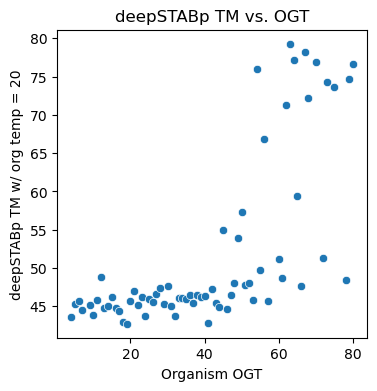

In [76]:
fig, ax = plt.subplots(figsize=(4,4))
g = sns.scatterplot(y=melting.set_index(0)[1], x=merged.set_index('accession').loc[melting[0].values, 'temperature'])
ax.set_xlabel('Organism OGT')
ax.set_ylabel('deepSTABp TM w/ org temp = 20')
ax.set_title('deepSTABp TM vs. OGT')

In [93]:
merged.set_index('accession').loc['RS_GCF_000426625.1']

organism_name                      Psychrilyobacter atlanticus DSM 19335
assembly                                                 GCA_000426625.1
temperature                                                         14.0
ncbi_genbank_assembly_accession                          GCA_000426625.1
species                                      Psychrilyobacter atlanticus
Name: RS_GCF_000426625.1, dtype: object

## ScooP predictions
```
RS_GCF_000153225.1
AF-A4C2E2-F1-model_v4.pd
SCooP prediction of protein af-a  chain  c
Delta Hm= -80.2 kcal/mol
Delta Cp= -1.69 kcal/(mol K)
Tm= 41.4   *degree~C
Delta Gr= -3.5 kcal/mol
Delta G(T) =  -80.2 *(1-(T+273.15)/ 314.6 )+ 1.69 *( 41.4 -T)+ 1.69 *(T+273.15)*log((T+273.15)/ 314.6 )
Temperature range [ -51.73 ; 56.45 ]
```
```
RS_GCF_000015285.1
AF-A1STI3-F1-model_v4.pdb
SCooP prediction of protein af-a  chain  s
Delta Hm= -128.6 kcal/mol
Delta Cp= -2.4 kcal/(mol K)
Tm= 47.9   *degree~C
Delta Gr= -7.2 kcal/mol
Delta G(T) =  -128.6 *(1-(T+273.15)/ 321.09 )+ 2.4 *( 47.9 -T)+ 2.4 *(T+273.15)*log((T+273.15)/ 321.09 )
Temperature range [ -55.86 ; 62.94 ]
```
```
RS_GCF_000745965.1
AF-A0A7G8BUM3-F1-model_v4.pdb
SCooP prediction of protein af-a  chain  a
Delta Hm= -109.3 kcal/mol
Delta Cp= -1.39 kcal/(mol K)
Tm= 52.9   *degree~C
Delta Gr= -7.6 kcal/mol
Delta G(T) =  -109.3 *(1-(T+273.15)/ 326.04 )+ 1.39 *( 52.9 -T)+ 1.39 *(T+273.15)*log((T+273.15)/ 326.04 )
Temperature range [ -91.58 ; 67.89 ]
```
```
RS_GCF_000196315.1
Croceibacter atlanticus
AF-A3U7I6-F1-model_v4.pdb
SCooP prediction of protein af-a  chain  u
Delta Hm= -58.8 kcal/mol
Delta Cp= -0.41 kcal/(mol K)
Tm= 48.2   *degree~C
Delta Gr= -3.9 kcal/mol
Delta G(T) =  -58.8 *(1-(T+273.15)/ 321.33 )+ 0.41 *( 48.2 -T)+ 0.41 *(T+273.15)*log((T+273.15)/ 321.33 )
Temperature range [ -188.48 ; 63.18 ]
```
```
RS_GCF_000426625.1
Psychrilyobacter atlanticus DSM 19335
AF-A0A369XT78-F1-model_v4.pdb
SCooP prediction of protein af-a  chain  a
Delta Hm= -96.1 kcal/mol
Delta Cp= -1.7 kcal/(mol K)
Tm= 53.3   *degree~C
Delta Gr= -6.2 kcal/mol
Delta G(T) =  -96.1 *(1-(T+273.15)/ 326.47 )+ 1.7 *( 53.3 -T)+ 1.7 *(T+273.15)*log((T+273.15)/ 326.47 )
Temperature range [ -55.35 ; 68.32 ]
```


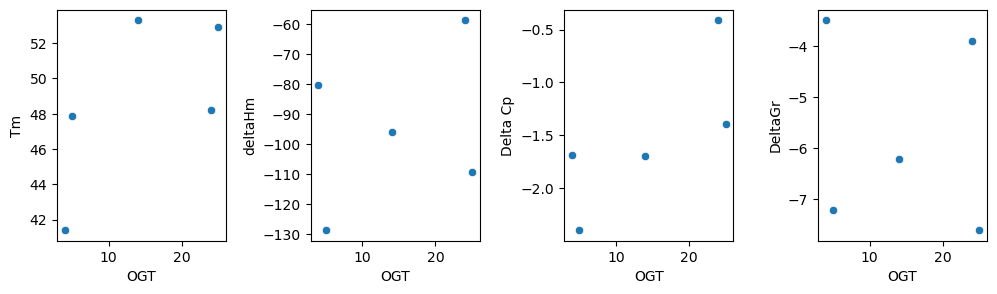

In [104]:
#
scoop_data = pd.read_csv('/data/mhoffert/fiererlab/ogt/results/Scoop_test.tsv.txt', sep='\t')
fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(1,4,1)
sns.scatterplot(data=scoop_data, x='OGT', y='Tm')
ax = fig.add_subplot(1,4,2)
sns.scatterplot(data=scoop_data, x='OGT', y='deltaHm')
ax = fig.add_subplot(1,4,3)
sns.scatterplot(data=scoop_data, x='OGT', y='Delta Cp')
ax = fig.add_subplot(1,4,4)
sns.scatterplot(data=scoop_data, x='OGT', y='DeltaGr')
fig.subplots_adjust(wspace=0.5)

In [100]:
scoop_data

,genome,deltaHm,Delta Cp,Tm,DeltaGr,OGT
0,RS_GCF_000153225.1,-80.2,-1.69,41.4,-3.5,4
1,RS_GCF_000015285.1,-128.6,-2.40,47.9,-7.2,5
2,RS_GCF_000745965.1,-109.3,-1.39,52.9,-7.6,25
3,RS_GCF_000196315.1,-58.8,-0.41,48.2,-3.9,24
4,RS_GCF_000426625.1,-96.1,-1.70,53.3,-6.2,14


In [58]:
adk_gene_id

'NZ_CH724148.1_191'

In [51]:
adk_gene_id

'NZ_CH724148.1_191'

In [14]:
merged

,organism_name,assembly,temperature,accession,ncbi_genbank_assembly_accession,species
0,Polaribacter irgensii 23-P,GCA_000153225.1,4.0,RS_GCF_000153225.1,GCA_000153225.1,Polaribacter irgensii
1,Polaribacter filamentus,GCA_002943715.1,4.0,RS_GCF_002943715.1,GCA_002943715.1,Polaribacter filamentus
2,Octadecabacter antarcticus 307,GCA_000155675.2,4.0,RS_GCF_000155675.2,GCA_000155675.2,Octadecabacter antarcticus
3,Octadecabacter arcticus 238,GCA_000155735.2,4.0,RS_GCF_000155735.2,GCA_000155735.2,Octadecabacter arcticus
4,Shewanella violacea DSS12,GCA_000091325.1,4.0,RS_GCF_000091325.1,GCA_000091325.1,Shewanella violacea
...,...,...,...,...,...,...
9359,Thermocrinis albus DSM 14484,GCA_000025605.1,80.0,RS_GCF_000025605.1,GCA_000025605.1,Thermocrinis albus
9360,Thermocrinis ruber,GCA_000512735.1,80.0,RS_GCF_000512735.1,GCA_000512735.1,Thermocrinis ruber
9361,Thermodesulfobacterium geofontis OPF15,GCA_000215975.1,80.0,RS_GCF_000215975.1,GCA_000215975.1,Thermodesulfobacterium geofontis
9362,Thermotoga petrophila RKU-1,GCA_000016785.1,80.0,RS_GCF_000016785.1,GCA_000016785.1,Thermotoga petrophila


In [16]:
merged['Genus'] = merged['accession'].apply(lambda x: gtdb_md.loc[x, 'gtdb_taxonomy'].split(';')[-2])

<AxesSubplot:xlabel='temperature', ylabel='temperature'>

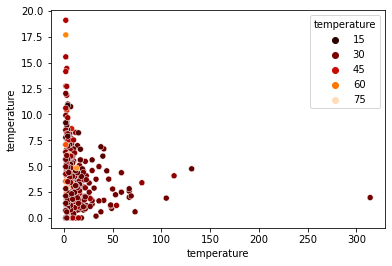

In [24]:
sns.scatterplot(y=merged.groupby('Genus').std()['temperature'],
                x=merged.groupby('Genus').count()['temperature'], 
                hue=merged.groupby('Genus').mean()['temperature'], palette='gist_heat')

In [161]:
from Bio.PDB import Select, PDBIO